In [5]:
!pip install vaderSentiment --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set(style="whitegrid")
%matplotlib inline

In [6]:
apps_df = pd.read_csv("googleplaystore.csv")
reviews_df = pd.read_csv("googleplaystore_user_reviews.csv")

print("Apps dataset shape:", apps_df.shape)
print("Reviews dataset shape:", reviews_df.shape)
apps_df.head()

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [8]:
print("Missing values:\n", apps_df.isnull().sum())
print("\nDuplicate rows:", apps_df.duplicated().sum())

Missing values:
 App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Duplicate rows: 483


In [9]:
# Drop duplicates
apps_df = apps_df.drop_duplicates(subset='App', keep='first')

# Drop rows with missing Rating (or impute with category median — here we impute)
apps_df['Rating'] = apps_df['Rating'].fillna(apps_df.groupby('Category')['Rating'].transform('median'))
apps_df = apps_df.dropna(subset=['Rating'])

# Clean 'Installs': remove '+' and ',' then convert to int
apps_df['Installs'] = apps_df['Installs'].astype(str).str.replace('[+,]', '', regex=True)
apps_df = apps_df[apps_df['Installs'].str.isnumeric()]
apps_df['Installs'] = apps_df['Installs'].astype(int)

# Clean 'Price': remove '$' then convert to float
apps_df['Price'] = apps_df['Price'].astype(str).str.replace('$', '', regex=False)
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce').fillna(0)

# Clean 'Size': convert 'M'/'k' to numeric MB, mark 'Varies with device' as NaN
def clean_size(x):
    x = str(x)
    if 'M' in x:
        return float(x.replace('M', ''))
    elif 'k' in x:
        return float(x.replace('k', '')) / 1024
    else:
        return np.nan

apps_df['Size_MB'] = apps_df['Size'].apply(clean_size)

# Clean 'Reviews' to numeric
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

print("Shape after cleaning:", apps_df.shape)
apps_df[['App', 'Category', 'Rating', 'Installs', 'Price', 'Size_MB', 'Reviews']].head()

Shape after cleaning: (9659, 14)


,App,Category,Rating,Installs,Price,Size_MB,Reviews
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,10000,0.0,19.0,159
1,Coloring book moana,ART_AND_DESIGN,3.9,500000,0.0,14.0,967
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,5000000,0.0,8.7,87510
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,50000000,0.0,25.0,215644
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,100000,0.0,2.8,967


/tmp/ipykernel_566/3042945430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


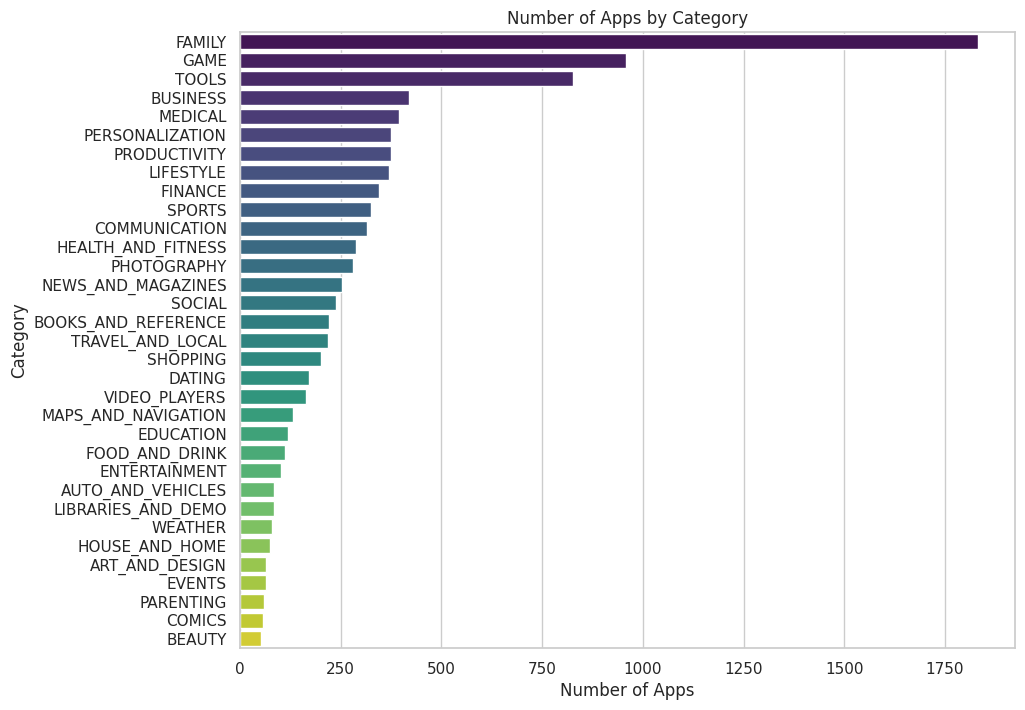

Most saturated categories:
 Category
FAMILY      1832
GAME         959
TOOLS        827
BUSINESS     420
MEDICAL      395
Name: count, dtype: int64


In [10]:
category_counts = apps_df['Category'].value_counts()

plt.figure(figsize=(10,8))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.show()

print("Most saturated categories:\n", category_counts.head(5))

Category choice: The FAMILY category is heavily saturated with 1832 apps,
suggesting high competition, while [need avg rating chart] shows fewer apps
but strong average ratings — a potentially easier space to stand out in.

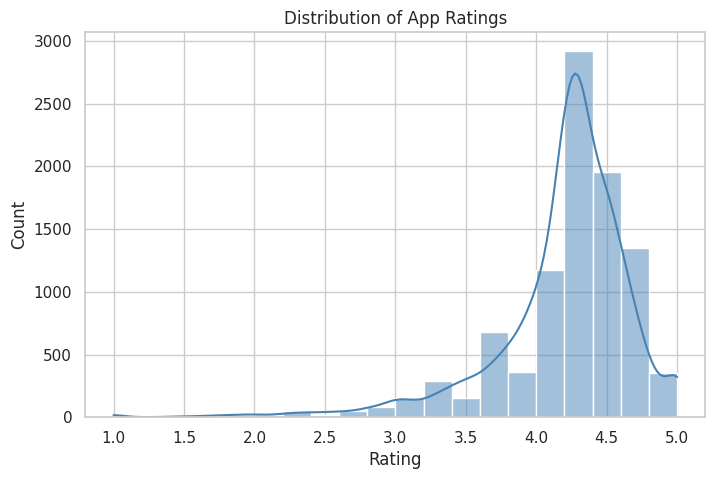

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(apps_df['Rating'], bins=20, kde=True, color='steelblue')
plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.show()

"The [most saturated category] category has the highest number of apps, indicating heavy competition for new entrants in that space."

/tmp/ipykernel_566/3918437974.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako')


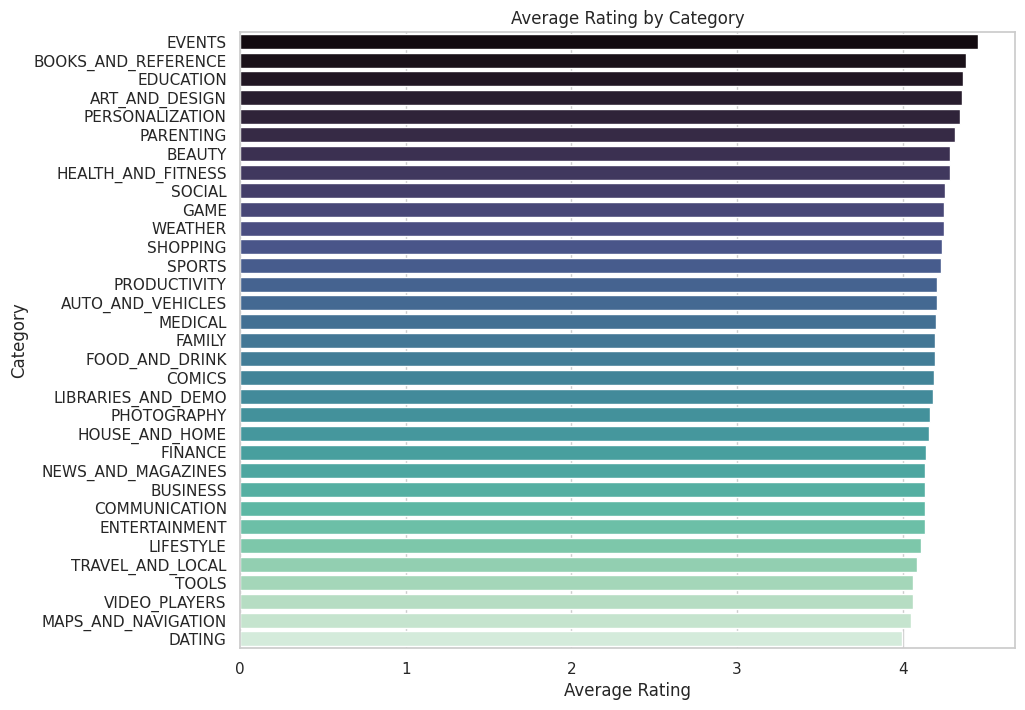

In [12]:
avg_rating_by_cat = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=avg_rating_by_cat.values, y=avg_rating_by_cat.index, palette='mako')
plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.show()

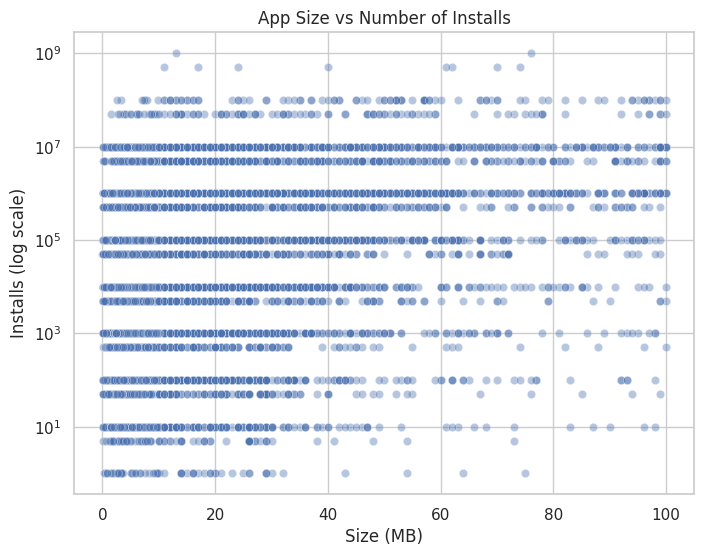

Correlation between Size and Installs: 0.134


In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Size_MB', y='Installs', data=apps_df, alpha=0.4)
plt.yscale('log')
plt.title("App Size vs Number of Installs")
plt.xlabel("Size (MB)")
plt.ylabel("Installs (log scale)")
plt.show()

correlation = apps_df[['Size_MB', 'Installs']].corr().iloc[0,1]
print(f"Correlation between Size and Installs: {correlation:.3f}")

/tmp/ipykernel_566/1404180023.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=apps_df, palette='Set2')


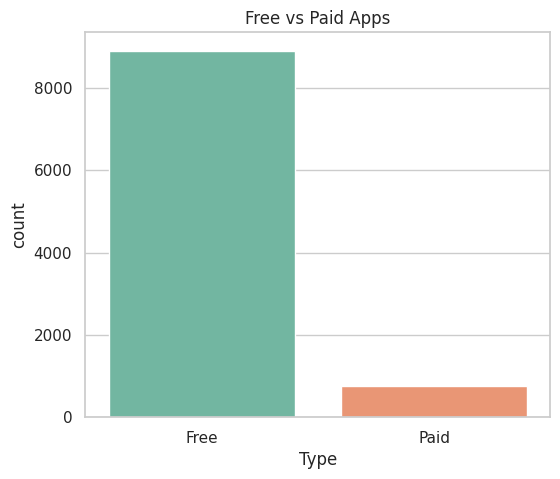

Type
Free    92.173103
Paid     7.826897
Name: proportion, dtype: float64


In [14]:
apps_df['Type'] = apps_df['Price'].apply(lambda x: 'Free' if x == 0 else 'Paid')

plt.figure(figsize=(6,5))
sns.countplot(x='Type', data=apps_df, palette='Set2')
plt.title("Free vs Paid Apps")
plt.show()

print(apps_df['Type'].value_counts(normalize=True) * 100)

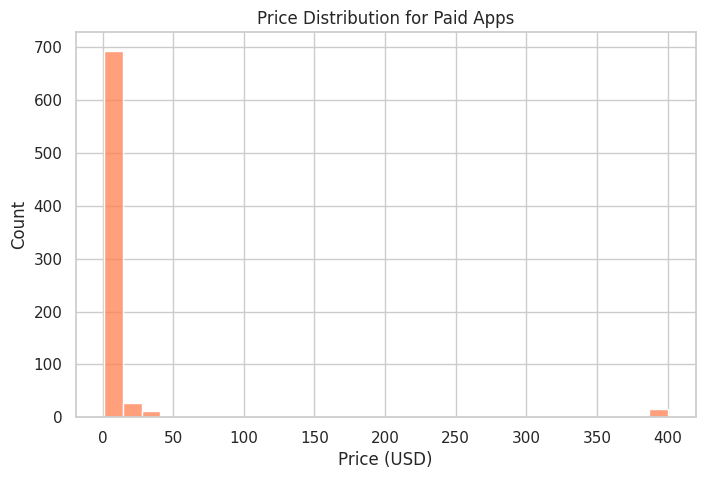

/tmp/ipykernel_566/3412891585.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='rocket')


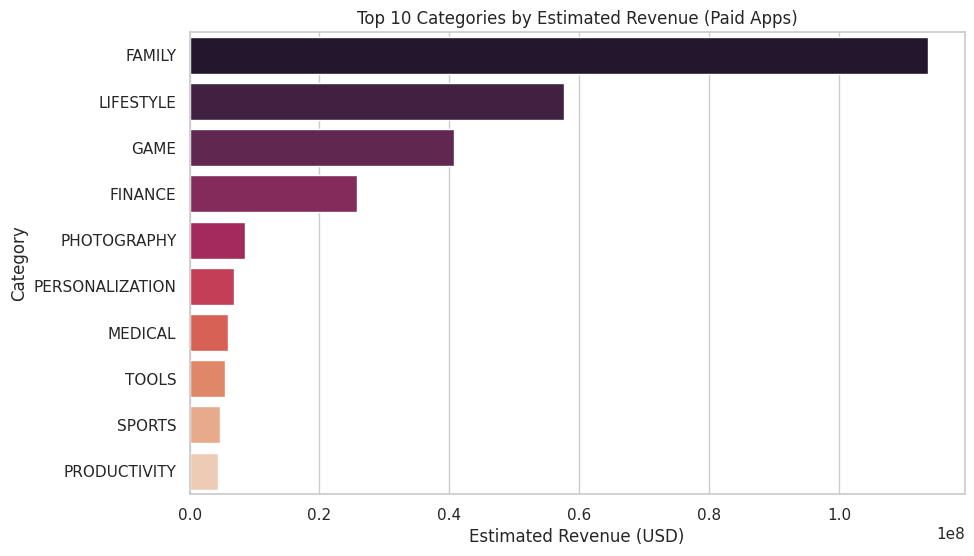

In [15]:
paid_apps = apps_df[apps_df['Type'] == 'Paid']

plt.figure(figsize=(8,5))
sns.histplot(paid_apps['Price'], bins=30, color='coral')
plt.title("Price Distribution for Paid Apps")
plt.xlabel("Price (USD)")
plt.show()

paid_apps = paid_apps.copy()
paid_apps['Estimated_Revenue'] = paid_apps['Price'] * paid_apps['Installs']

revenue_by_category = paid_apps.groupby('Category')['Estimated_Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='rocket')
plt.title("Top 10 Categories by Estimated Revenue (Paid Apps)")
plt.xlabel("Estimated Revenue (USD)")
plt.show()

Sentiment_VADER
Positive    25604
Negative     7522
Neutral      4301
Name: count, dtype: int64


/tmp/ipykernel_566/692062512.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment_VADER', data=reviews_clean, order=['Positive','Neutral','Negative'], palette='Set1')


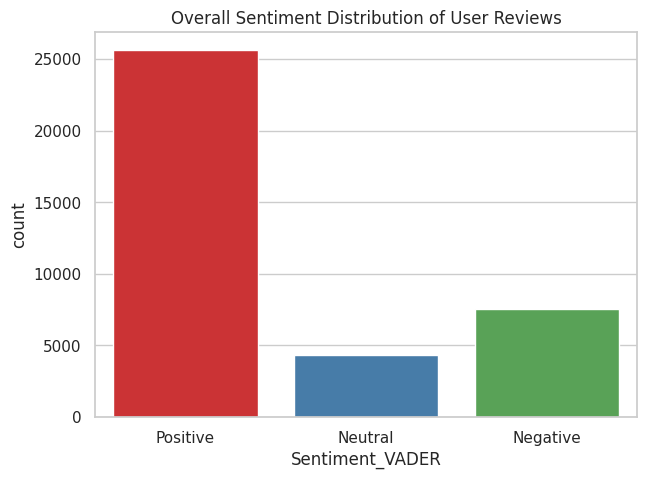

In [16]:
!pip install vaderSentiment --quiet

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

reviews_clean = reviews_df.dropna(subset=['Translated_Review']).copy()

analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

reviews_clean['Sentiment_VADER'] = reviews_clean['Translated_Review'].apply(get_sentiment)

print(reviews_clean['Sentiment_VADER'].value_counts())

plt.figure(figsize=(7,5))
sns.countplot(x='Sentiment_VADER', data=reviews_clean, order=['Positive','Neutral','Negative'], palette='Set1')
plt.title("Overall Sentiment Distribution of User Reviews")
plt.show()

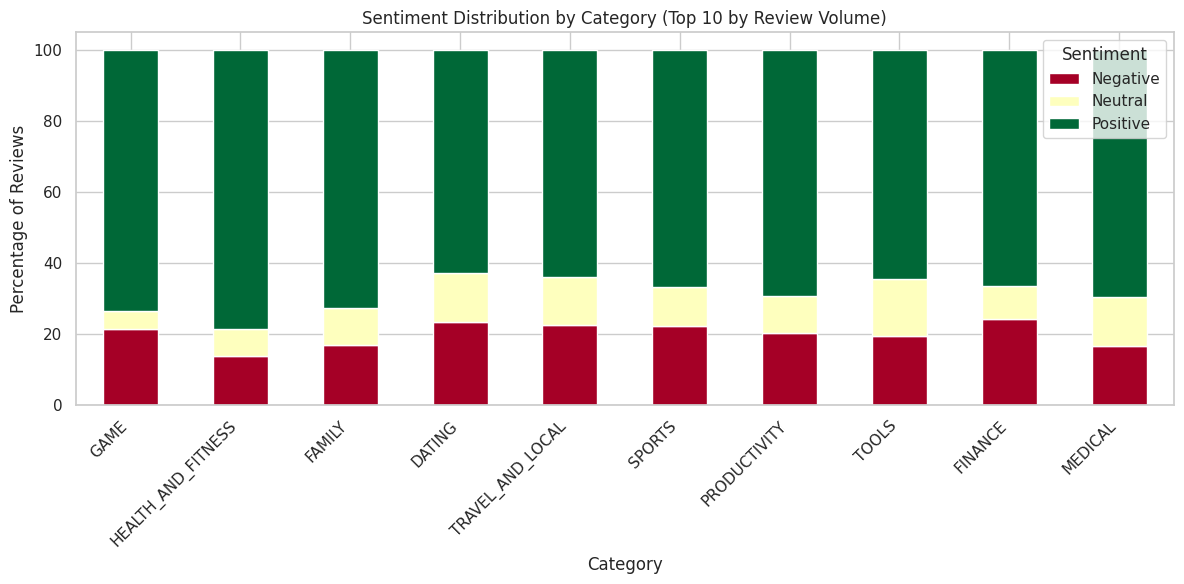

In [17]:
merged = reviews_clean.merge(apps_df[['App', 'Category']], on='App', how='inner')

sentiment_by_cat = merged.groupby(['Category', 'Sentiment_VADER']).size().unstack(fill_value=0)
sentiment_by_cat_pct = sentiment_by_cat.div(sentiment_by_cat.sum(axis=1), axis=0) * 100

top_categories = merged['Category'].value_counts().head(10).index
sentiment_by_cat_pct.loc[top_categories].plot(kind='bar', stacked=True, figsize=(12,6), colormap='RdYlGn')
plt.title("Sentiment Distribution by Category (Top 10 by Review Volume)")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

Category choice: The FAMILY category is heavily saturated with 1832 apps,
suggesting high competition, while niche categories like EVENTS and BEAUTY
have far fewer apps, potentially making them easier spaces to stand out in.

Pricing strategy: 92.17% of apps are free, with only 7.83% being paid.
Despite being a smaller share, the FAMILY category shows the highest
estimated revenue among paid apps, followed by LIFESTYLE and GAME,
suggesting strong monetization potential in these spaces.

User sentiment: The GAME category shows the most positive review sentiment
(smallest red/negative portion), indicating high user satisfaction — a
good benchmark. MEDICAL and FINANCE show the most negative sentiment
(largest red portions), suggesting room for a better competing product
if common complaints in these categories are addressed.